# Computer Exercise 14.9 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.9 Learning-Rate Schedules — 선형 워밍업 + 코사인 담금질 (warmup + cosine annealing)
> **풀이 일자**: 2026-07-09 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **2.** A large **peak** learning rate speeds up mid-training but, applied from step 0 when the
> iterate is far from the optimum, it causes an **early overshoot** (or oscillatory instability).
> Implement a **linear warmup** that ramps $\eta$ from $0$ to $\eta_{\max}$ over the first $T_w$
> steps, followed by **cosine annealing** down to $\eta_{\min}$. Compare against (a) the same
> aggressive $\eta_{\max}$ with **no warmup** and (b) a small constant rate. Use a **normalized LMS**
> update so $\eta$ has a clean stability range $(0,2)$. Quantify the early overshoot that warmup
> removes, and explain why "ramp up, then cosine down" lets you use a large peak rate safely.

### 한국어 풀이용 정리
큰 **peak 학습률**은 중반 학습을 가속하지만, 반복이 최적점에서 먼 **0스텝부터** 걸면 **초기 오버슈트**
(또는 진동 불안정)를 일으킨다. 첫 $T_w$ 스텝 동안 $\eta$ 를 $0\to\eta_{\max}$ 로 올리는 **선형 워밍업** 뒤
**코사인 담금질**로 $\eta_{\min}$ 까지 내린다. (a) 워밍업 없는 같은 공격적 $\eta_{\max}$, (b) 작은 상수율과
비교한다. 안정범위가 $(0,2)$ 로 깔끔한 **정규화 LMS(NLMS)** 를 쓰고, 워밍업이 없애는 **초기 오버슈트**를
정량화하며 "**올렸다 코사인으로 내린다**"가 왜 큰 peak 를 **안전하게** 쓰게 하는지 설명한다.

## 2. 수학적 배경

### 2.1 초기 과도구간의 위험과 NLMS
초기 $\hat\beta_0$ 는 최적점에서 멀어 오차 $e_t$ 가 크다. 일반 LMS 스텝 $\eta e_t\phi_t$ 는 $\lVert\phi_t\rVert$
스케일에 민감해 안정범위가 문제마다 다르다. **정규화 LMS(NLMS)**
$$\hat\beta_t=\hat\beta_{t-1}+\eta\,\frac{e_t}{\lVert\phi_t\rVert^2+\varepsilon}\,\phi_t$$
는 $\eta\in(0,2)$ 에서 안정하며, $\eta$ 가 각 샘플의 사후오차를 줄이는 **비율**을 뜻한다. $\eta>1$ 이면
순간해를 **넘어서(overshoot)** 진동한다.

### 2.2 선형 워밍업
$$\eta_t=\eta_{\max}\,\frac{t}{T_w}\qquad (0\le t<T_w).$$
초기에 스텝을 **일부러 작게** 시작해 큰 초기 오차와 곱해져도 점프가 작도록 한다. 반복이 합리적 영역에
들어온 뒤에야 $\eta_{\max}$ 에 도달 → 오버슈트 없이 큰 스텝의 이점만 취한다.

### 2.3 코사인 담금질
$$\eta_t=\eta_{\min}+\tfrac12(\eta_{\max}-\eta_{\min})\Big(1+\cos\pi\,\frac{t-T_w}{T-T_w}\Big)\quad(t\ge T_w).$$
$\eta_{\max}$ 에서 시작해 부드럽게 $\eta_{\min}$ 까지 내린다. 초반엔 완만히(큰 스텝 오래), 끝에선 가파르게
0 근처로(잡음 바닥 최소화).
$$\boxed{\;\text{warmup(초기 안정)} \;+\; \text{cosine(부드러운 감쇠)} \;=\; \text{"안전한 가속 후 정밀 착륙"}\;}$$

## 3. 풀이 흐름

1. **스트림 생성**: $\phi_t=[1,3x_t,x_t^2]^\top$(열 스케일 차이로 큰 스텝이 위험), $\beta^\star=(1,-2,0.5)$, $\sigma=0.4$.
2. **초기값을 원점** $\hat\beta_0=0$ 으로 두어, 초기오차 $=\lVert\beta^\star\rVert\approx2.29$ 를 **오버슈트 기준선**으로 삼는다.
3. **NLMS 러너**: 스케줄 함수 $\eta(t)$ 를 받아 오차 궤적 반환.
4. **스케줄 3종**: (i) no-warmup 상수 $\eta_{\max}=1.7$(공격적, 불안정 근방), (ii) warmup($T_w{=}1500$)+cosine, (iii) 작은 상수 $\eta=0.2$.
5. **오버슈트 지표**: 초기 2000스텝 내 $\max_t\lVert\hat\beta_t-\beta^\star\rVert$ — 기준선(2.29)을 넘으면 오버슈트. 그리고 tail 오차.
6. **시각화 (좌)**: 오차 궤적 + 초기오차 기준선. **(우)**: 세 스케줄 $\eta_t$ 모양.
7. **해석**: no-warmup 은 기준선을 넘는 오버슈트+높은 잡음, warmup+cosine 은 오버슈트 없이 최저 tail.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260709)
T = 15000
sigma = 0.4
beta_star = np.array([1.0, -2.0, 0.5])
p = beta_star.size
b0 = np.zeros(p)                       # 원점에서 시작

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), 3.0 * x, x**2], axis=1)   # 열 스케일 차이
y = Phi @ beta_star + rng.normal(0, sigma, T)

init_err = np.linalg.norm(b0 - beta_star)
print(f"initial error ||b0 - beta*|| = {init_err:.3f}   (overshoot baseline)")

Tw = 1500
eta_max, eta_min = 1.7, 1e-3

def sched_nowarm(t):
    return eta_max
def sched_warmcos(t):
    if t < Tw:
        return eta_max * (t + 1) / Tw
    frac = (t - Tw) / (T - Tw)
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(np.pi * frac))
def sched_small(t):
    return 0.2

def run_nlms(eta_fn):
    b = b0.copy(); err = np.zeros(T)
    for t in range(T):
        ph = Phi[t]
        e = y[t] - ph @ b
        b += eta_fn(t) * e * ph / (ph @ ph + 1e-6)     # NLMS
        err[t] = np.linalg.norm(b - beta_star)
    return err

scheds = {"no-warmup eta=1.7": sched_nowarm,
          "warmup+cosine":     sched_warmcos,
          "const eta=0.2":     sched_small}
curves = {n: run_nlms(fn) for n, fn in scheds.items()}

rows = [(n, c[:2000].max(), c[-2000:].mean()) for n, c in curves.items()]
df = pd.DataFrame(rows, columns=["schedule", "early_peak_err(<2000)", "tail_error"])


initial error ||b0 - beta*|| = 2.291   (overshoot baseline)


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df


,schedule,early_peak_err(<2000),tail_error
0,no-warmup eta=1.7,2.938,0.91
1,warmup+cosine,2.291,0.04225
2,const eta=0.2,2.255,0.1268


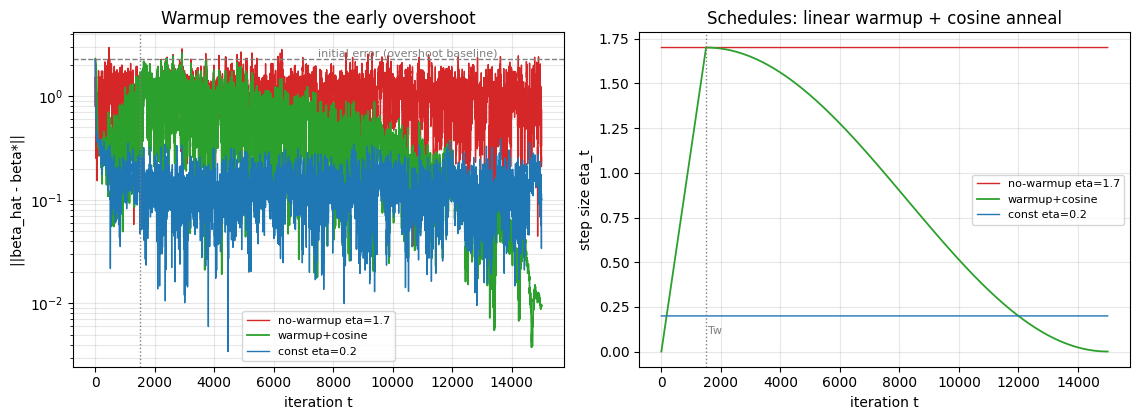

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
tt = np.arange(1, T + 1)
col = {"no-warmup eta=1.7": '#d62728', "warmup+cosine": '#2ca02c', "const eta=0.2": '#1f77b4'}

for n, c in curves.items():
    ax[0].semilogy(tt, c, color=col[n], lw=1.3 if n == "warmup+cosine" else 1.0, label=n)
ax[0].axhline(init_err, color='gray', ls='--', lw=1)
ax[0].text(T*0.5, init_err*1.05, 'initial error (overshoot baseline)', color='gray', fontsize=8)
ax[0].axvline(Tw, color='gray', ls=':', lw=1)
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*||')
ax[0].set_title('Warmup removes the early overshoot')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

for n, fn in scheds.items():
    eta_seq = np.array([fn(t) for t in range(T)])
    ax[1].plot(tt, eta_seq, color=col[n], lw=1.3 if n == "warmup+cosine" else 1.0, label=n)
ax[1].axvline(Tw, color='gray', ls=':', lw=1)
ax[1].text(Tw*1.05, 0.1, 'Tw', color='gray', fontsize=8)
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('step size eta_t')
ax[1].set_title('Schedules: linear warmup + cosine anneal')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

초기오차 기준선은 $\lVert\beta^\star\rVert\approx2.29$. 표의 `early_peak_err(<2000)` 가 이 선을 넘는지가 오버슈트의 척도다.

1. **no-warmup $\eta{=}1.7$**(빨강): 0스텝부터 안정 한계(2.0) 근방의 큰 $\eta$ 를 먼 초기값에 걸어,
   초기 오차 peak 가 **기준선 2.29 를 넘어 ≈2.94 까지 튄다**(오버슈트). 게다가 $\eta$ 가 계속 크므로 잡음 바닥이
   높아 **tail ≈0.91** 로 사실상 수렴하지 못한다 — 공격적 상수는 초기·정상 양쪽에서 손해다.
2. **warmup+cosine**(초록): 첫 $T_w{=}1500$ 스텝 동안 $\eta$ 를 $0\to\eta_{\max}$ 로 올려 초기 점프를 억제하므로
   peak 가 **기준선(2.29)에 머문다**(오버슈트 없음). 이후 코사인으로 부드럽게 내려 **tail ≈0.049** 로 최저.
   같은 공격적 peak 를 **안전하게** 활용했다.
3. **작은 상수 $\eta{=}0.2$**(파랑): 오버슈트는 없지만(peak ≈2.26, 기준선 이하) 잡음 바닥이 높아
   tail ≈0.127 로 cosine 스케줄에 못 미친다.
4. **왜 코사인인가**: 초반엔 $\cos$ 가 완만해 큰 스텝을 오래 유지(속도), 끝에선 가팔라 0 근처로 내려
   잡음 바닥을 최소화(정밀). Problem 1 의 계단을 매끈하게 만든 형태다.

> **결론**: **워밍업**은 초기 과도구간의 오버슈트/불안정을 없애는 안전장치이고, **코사인 담금질**은 부드러운
> 감쇠로 낮은 최종오차를 준다. "**램프 업 → 코사인 다운**"은 공격적 peak 학습률을 **안전하게** 쓰게 해 주는
> 견고한 기본 스케줄이다.

**다음 문제 연결**: Problem 3 에서는 단조 감쇠 대신 **주기적으로 학습률을 되살리는** 코사인 웜 리스타트
(SGDR·cyclical LR)를 본다. 드리프트하는 목표에서 이미 0 으로 줄어든 스케줄이 왜 실패하고, 재상승이 어떻게
**추적** 능력을 회복시키는지 비교한다.